# Dependencies

In [1]:
import sys
import os
import matplotlib.pyplot as plt 
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

module_dir = os.path.abspath('../script')  
sys.path.append(module_dir)

from skew_correction import skew_correction

2025-01-08 02:47:20.933292: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-08 02:47:20.933848: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 02:47:20.935914: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 02:47:20.941385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736275640.951083  371302 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736275640.95

# Skew Correction

In [2]:
all_images_folder = '../dataset/test_imgs/original_images'

for filename in os.listdir(all_images_folder):
    file_path = os.path.join(all_images_folder, filename)
    
    if os.path.isfile(file_path):
        skew_correction(file_path)

# Test Image and it's prediction

In [3]:
IMAGE_PATH = "../dataset/test_imgs/corrected_images/img_003.jpg"

In [4]:
# Print image with original size
def display_image_with_axes(im_data, dpi=100):

    if len(im_data.shape) == 3:
        height, width, depth = im_data.shape
    else:
        height, width = im_data.shape
    figsize = width / float(dpi), height / float(dpi)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(im_data, cmap='gray')
    plt.show()

# Apply preprocessing that is not done in skew correction
def apply_preprocess(img_path):
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    return gray

# Paragraph Segmentation

Sample contours: 


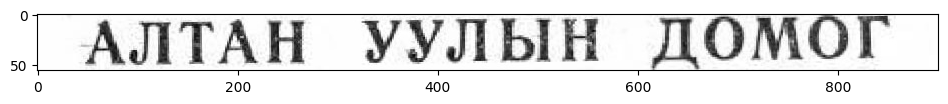

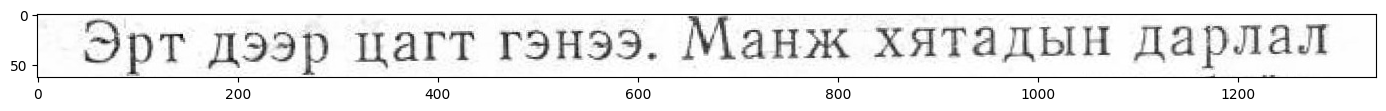

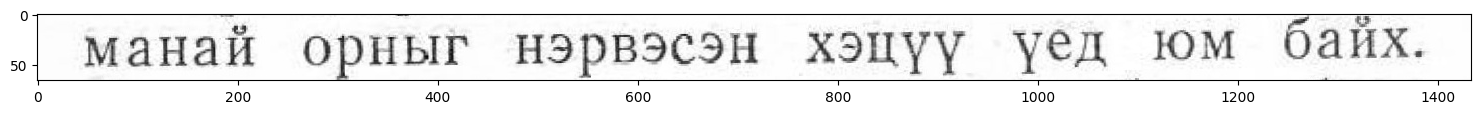

In [5]:
def get_contour_precedence(contour, cols):
    tolerance_factor = 61
    origin = cv2.boundingRect(contour)
    return ((origin[1] // tolerance_factor) * tolerance_factor) * cols + origin[0]

def sort_contours_by_y(contours):
    bounding_boxes = [cv2.boundingRect(c) for c in contours]    
    sorted_indices = sorted(range(len(bounding_boxes)), key=lambda k: bounding_boxes[k][1])
    
    return [contours[i] for i in sorted_indices]

def detect_cntr(img_path):
    image = apply_preprocess(img_path)

    ret,thresh = cv2.threshold(image,127,255,cv2.THRESH_BINARY_INV)

    kernel = np.ones((5,100), np.uint8)
    img_dilation = cv2.dilate(thresh, kernel, iterations=1)

    contours, h = cv2.findContours(img_dilation.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    

    image_area = image.shape[0] * image.shape[1]
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    largest_contour_area = w * h
    threshold_area = 0.95 * image_area
    if largest_contour_area >= threshold_area:
        contours = tuple(x for x in contours if x is not largest_contour)

    min_area = 1000
    contours_sorted = sort_contours_by_y(contours)

    filtered_contours = [contour for contour in contours_sorted if min_area <= cv2.contourArea(contour)]

    cropped_images = []
    print("Sample contours: ")
    for i, ctr in enumerate(filtered_contours):
        x, y, w, h = cv2.boundingRect(ctr)
        cropped_img = image[y:y+h, x:x+w]
        cropped_images.append(cropped_img)
        if i < 3:
            display_image_with_axes(cropped_img)
    return cropped_images

contour_images = detect_cntr(IMAGE_PATH)

# Line Segmentation

In [6]:
def thresholding(image, inv=True):
    if inv:
        ret, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        ret, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)
    return thresh

def line_segmentation_horizontal_projection(gray_image):
    _, binary = cv2.threshold(gray_image, 200, 255, cv2.THRESH_BINARY_INV)
    horizontal_projection = np.sum(binary, axis=1)

    threshold = (np.max(horizontal_projection) - np.min(horizontal_projection)) / 100
    lines = []
    start = None

    for i, value in enumerate(horizontal_projection):
        if value > threshold and start is None:  # Start of a line
            start = i
        elif value <= threshold and start is not None:  # End of a line
            end = i
            lines.append((start, end))
            start = None

    if start is not None:
        lines.append((start, len(horizontal_projection)))

    line_images = []
    for (start, end) in lines:
        x, y, w, h = 0, int(start), int(gray_image.shape[1]), int(end-start)
        line_images.append(gray_image[y:y+h, x:x+w])

    return line_images

Sample Line Segmentation:


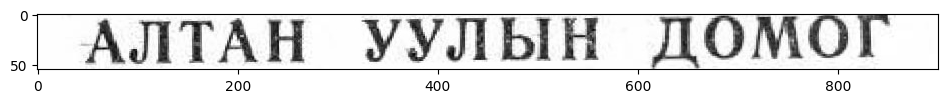

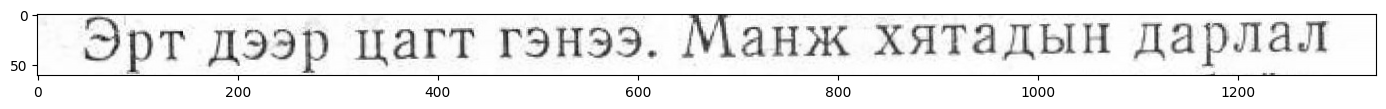

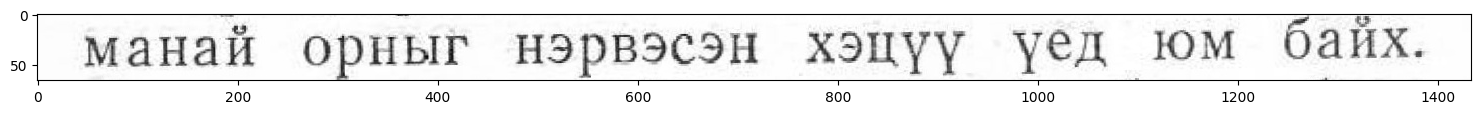

In [7]:
line_images_all = []
print("Sample Line Segmentation:")
for i in range(len(contour_images)):
    line_images = line_segmentation_horizontal_projection(contour_images[i])
    if line_images != None:
        for single_line in line_images:
            if single_line.shape[0] > 10: #change
                line_images_all.append(single_line)
                if i < 3:
                    display_image_with_axes(single_line)

# Word Segmentation

In [8]:
def cropp_line(line_image):
    thresh = thresholding(line_image)
    binary = line_image > thresh
    vertical_projection = np.sum(binary, axis=0)
    height = line_image.shape[0]
    index = 0
    while vertical_projection[index] == height:
        index += 1
    if index > 2:
        index -= 2
    line_image = line_image[:, index:]
    
    thresh = thresholding(line_image)
    binary = line_image > thresh
    vertical_projection = np.sum(binary, axis=0)
    
    index = line_image.shape[1] - 1
    while vertical_projection[index] == height:
        index -= 1
    if index < line_image.shape[1] - 1:
        index += 2
    
    line_image = line_image[:, :index]
    return line_image

def word_segmentation(line_image, display_result=False):
    line = cropp_line(line_image)
    dst = cv2.fastNlMeansDenoising(line, None, 12, 7, 21)
    thresh = thresholding(dst)
    kernel = np.ones((1, 1), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1) 
    binary = line > dilated
    vertical_projection = np.sum(binary, axis=0)
    
    height = line.shape[0]
    whitespace_lengths = []
    current_whitespace = 0
    for vp in vertical_projection:
        if vp == height:
            current_whitespace += 1
        elif current_whitespace:
            whitespace_lengths.append(current_whitespace)
            current_whitespace = 0

    if current_whitespace:
        whitespace_lengths.append(current_whitespace)

    avg_white_space_length = np.mean(whitespace_lengths)*1.5 if whitespace_lengths else 0
    
    divider_indexes = [0]
    current_whitespace = 0
    for index, vp in enumerate(vertical_projection):
        if vp == height:
            current_whitespace += 1
        else:
            if current_whitespace > avg_white_space_length:
                divider_indexes.append(index - current_whitespace // 2)
            current_whitespace = 0

    if display_result:
        line_copy = line.copy()
        mask = np.zeros_like(line_copy, dtype=bool)
        mask[:, divider_indexes] = True
        line_copy[mask] = 0

        plt.figure(figsize=(6,15))
        plt.imshow(line_copy, cmap="gray")
        plt.show()
    
    divider_indexes.append(len(vertical_projection))

    dividers = np.column_stack((divider_indexes[:-1], divider_indexes[1:]))
    
    words = [line[:, window[0]:window[1]] for window in dividers]

    return words

Sample Word Segmentation:


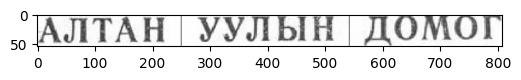

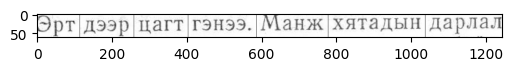

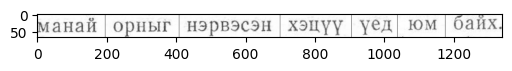

In [9]:
print("Sample Word Segmentation:")
words_images = []
for i in range(len(line_images_all)):
    if i < 3:
        words = word_segmentation(line_images_all[i], True)
    else:
        words = word_segmentation(line_images_all[i], False)
    words_images.append(words)

# Character Segmentation

In [10]:
def character_segmentation(image, visual):
    kernel = np.ones((1, 3), np.uint8)
    dilated = cv2.erode(image, kernel, iterations=2)
    
    denoised = cv2.fastNlMeansDenoising(dilated, None, h=30, templateWindowSize=7, searchWindowSize=21)
    
    _, binary = cv2.threshold(denoised, 170, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contours = sorted(contours, key=lambda ctr: cv2.boundingRect(ctr)[0])

    result_chars = []
    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)

        # Check if character height is much smaller than the width (indicating possible multi-letter segmentation)
        if w > 10 and h > 10:  # Ensure the character is large enough
            if h * 1.2 < w and h * 2 > w:  # If the width is much larger than the height, check the middle column
                mid_x = x + w // 2
                
                middle_column_sum = np.sum(binary[y:y + h, mid_x])
                # If the sum of pixels in the middle column is less than the threshold, split the character
                if middle_column_sum < h*255*0.3:
                    left_char = binary[y:y + h, x:mid_x]
                    right_char = binary[y:y + h, mid_x:x + w]

                    if visual:
                        display_image_with_axes(left_char, 20)
                        display_image_with_axes(right_char, 20)

                    result_chars.append(left_char)
                    result_chars.append(right_char)
                else:
                    # If the middle column has enough pixels, keep the entire character
                    char = binary[y:y + h, x:x + w]
                    if visual:
                        display_image_with_axes(char, 20)
                    result_chars.append(char)
            elif h * 2 < w:  # If width is much larger than height, split into 3 parts
                third_x1 = x + w // 3
                third_x2 = x + 2 * w // 3

                left_char = binary[y:y + h, x:third_x1]
                middle_char = binary[y:y + h, third_x1:third_x2]
                right_char = binary[y:y + h, third_x2:x + w]

                if visual:
                    display_image_with_axes(left_char, 20)
                    display_image_with_axes(middle_char, 20)
                    display_image_with_axes(right_char, 20)

                result_chars.append(left_char)
                result_chars.append(middle_char)
                result_chars.append(right_char)
            else:
                # If the character is not too wide, add the entire character
                char = binary[y:y + h, x:x + w]
                if visual:
                    display_image_with_axes(char, 50)
                result_chars.append(char)
    return result_chars


# Character Recognition

In [11]:
# Load the model and encoder
model_path = '/home/bat/Documents/code/mn_ocr_uchprak/final_mn_ocr/cnn_character_recognition_model.h5'
model = tf.keras.models.load_model(model_path)

encoder_path = '/home/bat/Documents/code/mn_ocr_uchprak/final_mn_ocr/label_classes.npy'
label_encoder = LabelEncoder()
label_encoder.classes_ = np.load(encoder_path, allow_pickle=True)

# Resize, normalize and make prediction
def predict_char(image, model, label_encoder):
    resized_image = cv2.resize(image, (28, 28))
    resized_image = resized_image.astype('float32') / 255.0
    resized_image = np.expand_dims(resized_image, axis=-1)
    resized_image = np.expand_dims(resized_image, axis=0)

    predictions = model.predict(resized_image)
    predicted_index = np.argmax(predictions)

    # Decode the predicted label
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    return predicted_label

2025-01-08 02:47:23.791115: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Saple Letter Segmentation


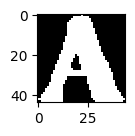

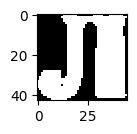

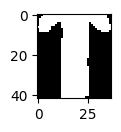

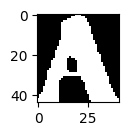

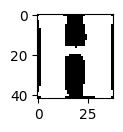

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━

In [12]:
result_full_text = ""
print("Saple Letter Segmentation")
for ind1, words in enumerate(words_images):
    result_line_text = ""
    for ind2, word in enumerate(words):
        result_word_text = ""
        if ind1 == 0 and ind2 == 0:
            characters = character_segmentation(word, True)
        else:
            characters = character_segmentation(word, False)
        for character in characters:
            predicted_char = predict_char(character, model, label_encoder)
            result_word_text = result_word_text + predicted_char
        result_line_text = result_line_text + result_word_text + " "
    result_full_text = result_full_text + result_line_text + "\n"

# Postprocess Text Output

In [13]:
def postprocess_text(input_string):
    replacements_dict = {
        "ь[": "Ы",
        "[[": "Н",
        "[": "Н",
        "][": "Н",
        "]]": "Н",
    }
    for key, value in replacements_dict.items():
        input_string = input_string.replace(key, value)
    return input_string

output_string = postprocess_text(result_full_text)
print(output_string)

АЛТАН УУЛЫН ДОМОГ 
ЭрТ ДЭЭр ЦаГТ ГЭНЭЭ М2НЖ ХЯТаДНН ДарЛ2Л 
УаНаИ ОРЦНГ НЭРВЭСЭШ ХЭЦҮҮ ҮӨД юМ баНОХ 
ӨРГӨН УУДаМ НУТГИИОН МааНь ӨНЦӨГ бУЛ2]Н 6ҮРТ 
ОЛ3 ХЯИСЭН ГаДааДНН ТҮРЭМГИИЛЭГЧИД аНГаУЭЛ 
ХУУРаИО ГОВь ЦӨЛИИГ Ч ГЯТЛаН 2ЛТ] МӨНГӨ Л ОЛЖ 
баИВаЛ ЯМь НаСаа ӨГӨХӨ№ 6УЦДаГГҮИО баИСаН 
ТЭр ЦаГ" ар МОНГОЛНН ШВь НУТ2ГТ аЛТ1аР ОҮТ 
СЭН НЭГ УУЛ 6аИЛаГ тУХаИ ИМ ЛаМЖСаН ЦУУ 
ЯрИа НЭГЭН баЯ]Н ТЭНГЭДНН СОНОРТ ХҮРЧ ГЭ]НЭЭ 
ХОВДОГ ЦНУНаХаИ ТаНГаД ХОЛНН ТЭр ]НХ аЛТНГ 
аВаХ юМСаН ГЭХЭЭС ХООЛ Н12И Нь ХООЛОИ РУУГаО 
ЯВЭХЭа 6ОЛЖУ ХОНОГИИН НОИН) Нь ХОИТ ЗҮГТ ХУЛ 
ЖИН) ӨДРИИОН 6ОДОЛУ ШӨНИИН ЗҮҮДЭНД аМЗР 3аЯа 
Ү3ЭХЭЭ 6аИЖЭЭ 
БаЯЖИХНН ДОН ННҮГЭЛСЭН 6аЯН ТаНГаЛ 6ЯИЖ 
СУУЖ ЦаДаХГҮИ 6ОЛЖ барЛаГ ЗарН1 6ИрЭа 6О 
ЛОГЧ НаРаа НЭГЭН ӨДӨР ЦУГЛУУЛЖУ УУЛНГ ТЭр 
ХЭВЭЭР Нь а1Са] Ч 6ОЛОХООР УрТ ГЭГ1ИИОН ЖИН 
ГИИОН ЦУВаа 6ЭЛТГЭЖУ 2ЛС ХОЛНН Ир МОНГОЛД 
6аИГаа аЛТа]Н УУЛНГ НУРааЖ аВааД ИР ГЭЖ ТУ 
ШааЖЭЭ ИРЭХ ЦаГ" 4ИНь ХЭРЭГ 6ОЛ]НО ГЭЖ ИХ 
ЦЭрЭГ ДаЛЛаН ЯВУУЛЖЭЭ Ө1ҮҮХЭН Ч ГЭСЭН 
аЛТ аМИНДЯа аШИГЛаХ ГЭНЭ91 Ө]ИГГҮИ Цаа]аЛН2 
ГЭЖ ТЭ